# 🔄 Corrected Stock Simulation — With Lead Time & Order Frequency

**Inputs required:**
- Your pre-calculated parameters sheet (Excel with headers as-is)
- `Consumption.xlsx` — monthly consumption data

**What this fixes vs the naive simulation:**
- ✅ Orders arrive after `ceil(LT_days / 30)` months, not instantly
- ✅ Normal mode: can only reorder once per lead-time window
- ✅ Stockout mode: reorder every month (emergency)
- ✅ Two stockout rates: overall (÷36) and active months only

## 📦 Step 0 — Imports

In [2]:
!pip install openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import math
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.3f}'.format)
pd.set_option('display.max_columns', 40)
print('✅ Ready')


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Ready


## 📂 Step 1 — Upload & load files

In [5]:
# ── File names — adjust if yours differ ───────────────────────────────────
FILE_PARAMS      = 'test_2.csv'          # your parameters file (CSV)
FILE_CONSUMPTION = 'Consumption.xlsx'    # monthly consumption
SHEET_CONS       = 'Consumption'         # sheet name inside it

# ── French month parser ───────────────────────────────────────────────────
FRENCH_MONTHS = {
    'janv':1,'févr':2,'mars':3,'avr':4,'mai':5,'juin':6,
    'juil':7,'août':8,'sept':9,'oct':10,'nov':11,'déc':12
}

def parse_french_month(s):
    try:
        parts = str(s).strip().split('-')
        m = FRENCH_MONTHS.get(parts[0].lower())
        y = int('20'+parts[1]) if len(parts[1]) == 2 else int(parts[1])
        if m:
            return pd.Timestamp(year=y, month=m, day=1)
    except:
        pass
    return pd.NaT

# ── Load parameters from CSV ──────────────────────────────────────────────
raw = pd.read_csv(FILE_PARAMS)

raw.columns = raw.columns.str.strip()
raw['Article'] = raw['Article'].astype(str).str.strip()

# Keep only rows that have a valid article number (drop blank rows)
params = raw[raw['Article'].str.match(r'^\d+$')].copy().reset_index(drop=True)

print(f'✅ Parameters loaded: {params.shape[0]} articles')
print('Columns:', params.columns.tolist())
display(params.head(3))

✅ Parameters loaded: 1179 articles
Columns: ['Article', 'Désignation article', 'Unit', 'Source', 'ABC', 'HML', 'Lead Time (Days)', 'Lead Time (Months)', 'Unit Cost', 'Total Consumption', 'MaxMonthlyDemand', 'MinNonZeroDemand', 'ActiveMonths', 'AvgMonthlyDemand', 'sum/active months', 'StdMonthlyDemand', 'AvgDailyDemand', 'StdDailyDemand', 'Coefficient of Variation (CV)', 'XYZ classification', 'Service Level', 'Z factor', 'Safety Stock (SS) (M1: Daily)', 'Safety Stock (SS) (M2: Monthly)', 'Reorder Point (ROP) (M1: Daily)', 'Reorder Point (ROP) (m2: Monthly)', 'Annual demand (D)', 'Holding cost per unit', 'EOQ (Economic Order Quantity)', 'Stock Min', 'Stock Max', 'Orders per year']


,Article,Désignation article,Unit,Source,ABC,HML,Lead Time (Days),Lead Time (Months),Unit Cost,Total Consumption,MaxMonthlyDemand,MinNonZeroDemand,ActiveMonths,AvgMonthlyDemand,sum/active months,StdMonthlyDemand,AvgDailyDemand,StdDailyDemand,Coefficient of Variation (CV),XYZ classification,Service Level,Z factor,Safety Stock (SS) (M1: Daily),Safety Stock (SS) (M2: Monthly),Reorder Point (ROP) (M1: Daily),Reorder Point (ROP) (m2: Monthly),Annual demand (D),Holding cost per unit,EOQ (Economic Order Quantity),Stock Min,Stock Max,Orders per year
0,83520000,Achat Consommables Industriel,PC,Mixed Source,B,H,109.338,3.645,"1,212.176",685.000,274.000,2.000,9,19.028,76.111,54.876,0.865,11.700,2.884,Z,0.950,1.650,201.854,172.857,296.420,242.206,228.333,242.435,16.809,242.206,259.015,13.584
1,76210012,Rouleau doseur 61x1350mm,PC,Import,B,H,283.200,9.440,903.070,17.000,3.000,1.000,14,0.472,1.214,0.696,0.021,0.148,1.475,Z,0.950,1.650,4.122,3.530,10.201,7.988,5.667,180.614,3.068,7.988,11.056,1.847
2,86100028,VIS CONE MOBILE M52X300 L639 TH,PC,Local,B,H,15.800,0.527,808.000,44.000,7.000,1.000,14,1.222,3.143,1.884,0.056,0.402,1.541,Z,0.950,1.650,2.634,2.256,3.512,2.900,14.667,161.600,5.218,2.900,8.118,2.811


In [6]:
# ── Load consumption & build pivot ────────────────────────────────────────
df_cons = pd.read_excel(FILE_CONSUMPTION, sheet_name=SHEET_CONS)

df_cons.columns = df_cons.columns.str.strip()
df_cons['Article'] = df_cons['Article'].astype(str).str.strip()

# Convert French month text to datetime
df_cons['Date'] = df_cons['Month'].apply(parse_french_month)

# Withdrawals are negative → convert to positive consumption
df_cons['Consumption'] = df_cons['Valeur'].abs()

# Keep only valid dates
df_cons = df_cons[df_cons['Date'].notna()]

# Articles × months matrix (missing months → 0)
pivot = (
    df_cons
    .pivot_table(
        index='Article',
        columns='Date',
        values='Consumption',
        aggfunc='sum'
    )
    .fillna(0)
)

print('✅ Consumption loaded')
print(f'   Date range : {pivot.columns.min().strftime("%b-%Y")} → {pivot.columns.max().strftime("%b-%Y")}')
print(f'   Articles   : {pivot.shape[0]}')
print(f'   Months     : {pivot.shape[1]}')

✅ Consumption loaded
   Date range : Jan-2023 → Dec-2025
   Articles   : 1179
   Months     : 36


## 🔄 Step 2 — Simulation engine

In [7]:
def simulate_article(art_series, rop, eoq, lead_time_days):
    """
    Simulate stock evolution for one article over its full consumption history.

    Parameters
    ----------
    art_series     : pd.Series  index=dates, values=monthly consumption
    rop            : float      reorder point (units)
    eoq            : float      order quantity (units)
    lead_time_days : float      supplier lead time in calendar days

    Returns
    -------
    summary : dict   — KPIs
    trace   : list   — month-by-month detail
    """

    import math

    # Lead time in months
    # Example:
    # 27 days  -> 1 month
    # 109 days -> 4 months
    lt_months = max(1, math.ceil(lead_time_days / 30))

    # Starting stock
    stock = rop + (eoq / 2) if eoq > 0 else rop * 2

    on_order = {}          # {arrival_month_index: quantity}
    last_order_month = -999

    stockouts = 0
    orders = 0
    total_demand = 0
    unfilled = 0

    trace = []

    months = list(art_series.items())
    n = len(months)

    for i, (date, demand) in enumerate(months):

        # 1. Receive incoming orders
        received = on_order.pop(i, 0)
        stock += received

        # 2. Consume demand
        stock_before = stock
        stock -= demand

        total_demand += demand

        # 3. Detect stockout
        in_stockout = stock < 0

        if in_stockout:
            stockouts += 1
            unfilled += abs(stock)
            stock = 0

        # 4. Reordering logic
        months_since_last = i - last_order_month

        if in_stockout:
            can_order = True
        else:
            can_order = months_since_last >= lt_months

        order_placed = False
        order_qty = 0

        if stock <= rop and eoq > 0 and can_order:

            arrival = i + lt_months

            # Only add if inside simulation period
            if arrival < n:
                on_order[arrival] = on_order.get(arrival, 0) + eoq

            last_order_month = i
            order_placed = True
            order_qty = eoq
            orders += 1

        # 5. Save trace row
        trace.append({
            'Date'         : date,
            'Received'     : round(received, 2),
            'Demand'       : round(demand, 2),
            'Stock_Before' : round(stock_before, 2),
            'Stock_After'  : round(max(stock, 0), 2),
            'Stockout'     : in_stockout,
            'Order_Placed' : order_placed,
            'Order_Qty'    : round(order_qty, 2),
            'LT_Months'    : lt_months,
        })

    # ── KPIs ──────────────────────────────────────────────────────────────
    active_months = int((art_series > 0).sum())

    summary = {
        'LT_Months'             : lt_months,
        'Stockout_Months'       : stockouts,
        'Stockout_Rate_Overall' : round(stockouts / n * 100, 2) if n > 0 else 0,
        'Stockout_Rate_Active'  : round(stockouts / active_months * 100, 2) if active_months > 0 else 0,
        'Fill_Rate_Pct'         : round((1 - unfilled / total_demand) * 100, 2) if total_demand > 0 else 100.0,
        'Total_Orders'          : orders,
        'Avg_Orders_Year'       : round(orders / (n / 12), 2) if n > 0 else 0,
        'Active_Months'         : active_months,
        'Total_Demand'          : round(total_demand, 2),
        'Unfilled_Demand'       : round(unfilled, 2),
    }

    return summary, trace


print('✅ simulate_article() ready')
print()
print('Rules:')
print('  LT months    = ceil(lead_time_days / 30)')
print('  Normal order = only if months_since_last_order >= lt_months')
print('  Stockout     = order every month (emergency recovery)')
print('  Arrival      = scheduled at month index i + lt_months')

✅ simulate_article() ready

Rules:
  LT months    = ceil(lead_time_days / 30)
  Normal order = only if months_since_last_order >= lt_months
  Stockout     = order every month (emergency recovery)
  Arrival      = scheduled at month index i + lt_months


## ▶️ Step 3 — Run for all articles

In [8]:
# ── Column mapping — exact header names from your file ────────────────────
COL_ARTICLE = 'Article'
COL_LT_DAYS = 'Lead Time (Days)'
COL_ROP     = 'Reorder Point (ROP) (m2: Monthly)'
COL_EOQ     = 'EOQ (Economic Order Quantity)'

print('Running simulation …')

records = []

for _, row in params.iterrows():

    art = str(row[COL_ARTICLE]).strip()

    # Safe numeric conversion
    rop = pd.to_numeric(row[COL_ROP], errors='coerce')
    eoq = pd.to_numeric(row[COL_EOQ], errors='coerce')
    lt  = pd.to_numeric(row[COL_LT_DAYS], errors='coerce')

    # Skip invalid rows
    if pd.isna(rop) or pd.isna(eoq) or pd.isna(lt):
        continue

    # Skip articles not found in consumption pivot
    if art not in pivot.index:
        continue

    art_series = pivot.loc[art]

    summary, _ = simulate_article(
        art_series=art_series,
        rop=rop,
        eoq=eoq,
        lead_time_days=lt
    )

    summary['Article'] = art

    records.append(summary)

# Build final dataframe
df_sim = pd.DataFrame(records)

print(f'✅ Done — {len(df_sim)} articles simulated')
print()

print(f"Articles with ≥1 stockout month : {(df_sim['Stockout_Months'] > 0).sum()}")
print(f"Avg fill rate                   : {df_sim['Fill_Rate_Pct'].mean():.1f}%")
print(f"Avg stockout rate (÷ all months): {df_sim['Stockout_Rate_Overall'].mean():.1f}%")
print(f"Avg stockout rate (÷ active mo) : {df_sim['Stockout_Rate_Active'].mean():.1f}%")

Running simulation …
✅ Done — 1179 articles simulated

Articles with ≥1 stockout month : 489
Avg fill rate                   : 91.5%
Avg stockout rate (÷ all months): 3.6%
Avg stockout rate (÷ active mo) : 15.2%


In [9]:
# ── Merge simulation results back into parameters ─────────────────────────
results = params.merge(df_sim, on='Article', how='left')

print('Final table shape:', results.shape)

display(
    results[[
        'Article',
        'Désignation article',
        'ABC',
        'HML',
        'Lead Time (Days)',
        'LT_Months',
        'Reorder Point (ROP) (m2: Monthly)',
        'EOQ (Economic Order Quantity)',
        'Stockout_Months',
        'Stockout_Rate_Overall',
        'Stockout_Rate_Active',
        'Fill_Rate_Pct',
        'Total_Orders',
        'Avg_Orders_Year'
    ]]
    .sort_values('Stockout_Rate_Active', ascending=False)
    .head(20)
    .reset_index(drop=True)
    .style
    .format({
        'Stockout_Rate_Overall': '{:.1f}%',
        'Stockout_Rate_Active' : '{:.1f}%',
        'Fill_Rate_Pct'        : '{:.1f}%',
        'Lead Time (Days)'     : '{:.0f}',
    })
    .background_gradient(
        subset=['Stockout_Rate_Active'],
        cmap='Reds'
    )
)

Final table shape: (1179, 42)


,Article,Désignation article,ABC,HML,Lead Time (Days),LT_Months,Reorder Point (ROP) (m2: Monthly),EOQ (Economic Order Quantity),Stockout_Months,Stockout_Rate_Overall,Stockout_Rate_Active,Fill_Rate_Pct,Total_Orders,Avg_Orders_Year
0,92010014,"SACS Ciment CEM II 42,5 3plis 70gr/m?",C,L,52,2,2632.116261,2860.062779,1,2.8%,100.0%,50.8%,1,0.330000
1,10010083,ANKRAL R8 CB B620 L300,C,L,0,1,0.000000,30.750313,1,2.8%,100.0%,12.8%,1,0.330000
2,10020033,ANKRAL CKMAJ-3 BP20,C,L,44,2,5.982005,13.552923,1,2.8%,100.0%,63.8%,1,0.330000
3,10010085,ANKRAL R8 CB PB 200 L300,C,L,0,1,0.000000,5.884512,1,2.8%,100.0%,58.9%,1,0.330000
4,35270001,CONTREPLAQUÉ 4mm²,C,L,8,1,1.740020,11.373039,1,2.8%,100.0%,49.5%,1,0.330000
5,50160002,CABLE CUIVRE U1000R2V 3X120mm?,C,L,44,2,35.892029,32.249396,1,2.8%,100.0%,43.4%,2,0.670000
6,10030103,BRIQUE MLA RP201 KROSAKI,C,L,0,1,0.000000,2.605740,1,2.8%,100.0%,65.1%,1,0.330000
7,10020034,ANKRAL CKMAJ-3 BP+20,C,L,44,2,11.964010,19.166727,1,2.8%,100.0%,53.9%,1,0.330000
8,89010108,RESSORT DE PRESSION P SYS.HORIZONTAL,C,L,44,2,14.057711,21.976639,1,2.8%,100.0%,53.3%,1,0.330000
9,70030003,GODET630/320/4 AVEC 2 RANGÉ DE 6TROU,C,L,5,1,0.458613,4.363527,1,2.8%,100.0%,52.8%,1,0.330000


## 🔍 Step 4 — Single article trace
Change `ARTICLE_CODE` to inspect any article month by month.

In [16]:
import pandas as pd
import math

ARTICLE_CODE = '83520000'   # ← change this

# ─────────────────────────────────────────────────────────────
# Get article row safely
# ─────────────────────────────────────────────────────────────
row = params[params['Article'] == ARTICLE_CODE]

if row.empty:
    print(f'Article {ARTICLE_CODE} not found.')
else:
    row = row.iloc[0]

    rop = float(row[COL_ROP])
    eoq = float(row[COL_EOQ])
    lt  = float(row[COL_LT_DAYS])

    lt_months = max(1, math.ceil(lt / 30))

    art_name = str(row['Désignation article'])[:55]

    # ─────────────────────────────────────────────────────────
    # Get full time series (IMPORTANT FIX)
    # ─────────────────────────────────────────────────────────
    if ARTICLE_CODE not in pivot.index:
        print('No consumption data found.')
    else:

        art_series = pivot.loc[ARTICLE_CODE]

        summary, trace = simulate_article(art_series, rop, eoq, lt)
        df_trace = pd.DataFrame(trace)

        # Ensure datetime is clean
        df_trace['Date'] = pd.to_datetime(df_trace['Date'], errors='coerce')
        df_trace = df_trace.sort_values('Date')

        # ─────────────────────────────────────────────────────
        # PROFILE OUTPUT
        # ─────────────────────────────────────────────────────
        print('═' * 60)
        print(f'  Article   : {ARTICLE_CODE}')
        print(f'  Name      : {art_name}')
        print(f'  ABC / HML : {row["ABC"]} / {row["HML"]}')
        print(f'  Lead time : {lt:.0f} days → {lt_months} months')
        print(f'  ROP       : {rop:.2f}   EOQ: {eoq:.2f}')
        print('─' * 60)
        print(f'  Stockout months      : {summary["Stockout_Months"]}')
        print(f'  Stockout rate (÷36)  : {summary["Stockout_Rate_Overall"]}%')
        print(f'  Stockout rate (active): {summary["Stockout_Rate_Active"]}%')
        print(f'  Fill rate            : {summary["Fill_Rate_Pct"]}%')
        print(f'  Orders placed        : {summary["Total_Orders"]}')
        print('═' * 60)

        # ─────────────────────────────────────────────────────
        # FULL TIME DISPLAY (NO LOSS OF MONTHS)
        # ─────────────────────────────────────────────────────
        show = df_trace.copy()

        show['Date'] = show['Date'].dt.strftime('%b-%Y')

        show['Stockout'] = show['Stockout'].map({True: '⚠ YES', False: ''})

        show['Order'] = show.apply(
            lambda r: f'✅ {r["Order_Qty"]:.0f} units ordered'
            if r['Order_Placed'] else '',
            axis=1
        )

        show['Received'] = show['Received'].apply(
            lambda x: f'📦 +{x:.0f}' if x > 0 else ''
        )

        display(
            show[[
                'Date',
                'Demand',
                'Received',
                'Stock_Before',
                'Stock_After',
                'Stockout',
                'Order'
            ]].reset_index(drop=True)
        )

════════════════════════════════════════════════════════════
  Article   : 83520000
  Name      : Achat Consommables Industriel
  ABC / HML : B / H
  Lead time : 109 days → 4 months
  ROP       : 242.21   EOQ: 16.81
────────────────────────────────────────────────────────────
  Stockout months      : 4
  Stockout rate (÷36)  : 11.11%
  Stockout rate (active): 44.44%
  Fill rate            : 44.73%
  Orders placed        : 6
════════════════════════════════════════════════════════════


,Date,Demand,Received,Stock_Before,Stock_After,Stockout,Order
0,Jan-2023,0.000,,250.610,250.610,,
1,Feb-2023,0.000,,250.610,250.610,,
2,Mar-2023,0.000,,250.610,250.610,,
3,Apr-2023,0.000,,250.610,250.610,,
4,May-2023,0.000,,250.610,250.610,,
5,Jun-2023,0.000,,250.610,250.610,,
6,Jul-2023,0.000,,250.610,250.610,,
7,Aug-2023,0.000,,250.610,250.610,,
8,Sep-2023,0.000,,250.610,250.610,,
9,Oct-2023,0.000,,250.610,250.610,,


## 📊 Step 5 — Stock trace chart

ConversionError: Failed to convert value(s) to axis units: [NaT, NaT]

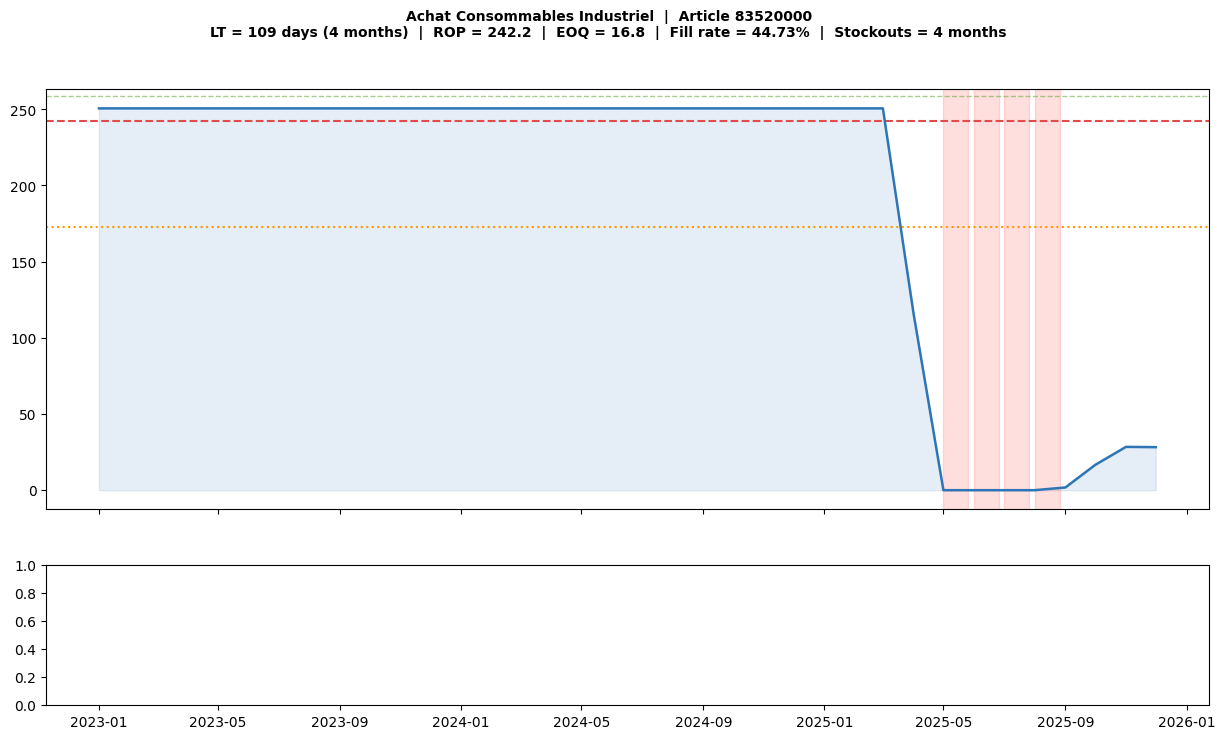

In [17]:
# ── Plot inventory simulation trace ───────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(15, 8),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

fig.suptitle(
    f'{art_name}  |  Article {ARTICLE_CODE}\n'
    f'LT = {lt:.0f} days ({lt_months} months)  |  '
    f'ROP = {rop:.1f}  |  EOQ = {eoq:.1f}  |  '
    f'Fill rate = {summary["Fill_Rate_Pct"]}%  |  '
    f'Stockouts = {summary["Stockout_Months"]} months',
    fontsize=10,
    fontweight='bold'
)

dates = df_trace['Date']
stock = df_trace['Stock_After']

# ── Stock level line ──────────────────────────────────────────────────────
ax1.fill_between(
    dates,
    stock,
    alpha=0.12,
    color='#2E75B6'
)

ax1.plot(
    dates,
    stock,
    color='#2E75B6',
    linewidth=1.8,
    label='Stock level',
    zorder=3
)

# ── Reference lines ───────────────────────────────────────────────────────
ax1.axhline(
    rop,
    color='#E24B4A',
    linestyle='--',
    linewidth=1.5,
    label=f'ROP = {rop:.1f}'
)

ss_val = float(row['Safety Stock (SS) (M2: Monthly)'])

ax1.axhline(
    ss_val,
    color='#FF9900',
    linestyle=':',
    linewidth=1.5,
    label=f'Safety stock = {ss_val:.1f}'
)

stock_max = float(row['Stock Max'])

ax1.axhline(
    stock_max,
    color='#70AD47',
    linestyle='--',
    linewidth=1,
    alpha=0.6,
    label=f'Stock Max = {stock_max:.1f}'
)

# ── Highlight stockout periods ────────────────────────────────────────────
for _, r in df_trace[df_trace['Stockout']].iterrows():

    ax1.axvspan(
        r['Date'],
        r['Date'] + pd.DateOffset(days=25),
        color='#FF4C4C',
        alpha=0.18,
        zorder=1
    )

so_count = df_trace['Stockout'].sum()

if so_count:
    ax1.axvspan(
        pd.NaT,
        pd.NaT,
        color='#FF4C4C',
        alpha=0.18,
        label=f'Stockout ({so_count} months)'
    )

# ── Order placements and receipts ─────────────────────────────────────────
ord_mask = df_trace['Order_Placed']
recv_mask = df_trace['Received'] > 0

# Orders placed ▲
ax1.scatter(
    df_trace[ord_mask]['Date'],
    df_trace[ord_mask]['Stock_After'],
    marker='^',
    color='purple',
    s=70,
    zorder=5,
    label=f'Order placed ({ord_mask.sum()}×)'
)

# Orders received ▼
ax1.scatter(
    df_trace[recv_mask]['Date'],
    df_trace[recv_mask]['Stock_After'],
    marker='v',
    color='#185FA5',
    s=70,
    zorder=5,
    label=f'Order received ({recv_mask.sum()}×)'
)

# ── Main chart formatting ─────────────────────────────────────────────────
ax1.set_ylabel('Stock (units)')

ax1.legend(
    fontsize=8,
    loc='upper right',
    ncol=2
)

ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

ax1.grid(True, alpha=0.3)

# ── Demand bars ───────────────────────────────────────────────────────────
ax2.bar(
    dates,
    df_trace['Demand'],
    color='#5B9BD5',
    width=20,
    alpha=0.8
)

ax2.set_ylabel('Monthly demand')
ax2.set_xlabel('Month')

ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

ax2.grid(True, alpha=0.3)

# ── Save and display ──────────────────────────────────────────────────────
plt.tight_layout()

fname = f'trace_{ARTICLE_CODE}.png'

plt.savefig(
    fname,
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(f'Saved → {fname}')

## 📤 Step 6 — Export results to Excel

In [18]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

OUTPUT = 'Simulation_Results_Corrected.xlsx'

thin = Side(style='thin', color='BFBFBF')

def write_sheet(ws, df, header_bg='1F3864'):
    for j, col in enumerate(df.columns):
        c = ws.cell(1, j+1, str(col))
        c.font      = Font(bold=True, color='FFFFFF', size=10, name='Arial')
        c.fill      = PatternFill('solid', fgColor=header_bg)
        c.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
        c.border    = Border(left=thin, right=thin, top=thin, bottom=thin)
        ws.column_dimensions[get_column_letter(j+1)].width = max(12, min(len(str(col))+3, 32))
    ws.row_dimensions[1].height = 30
    ws.freeze_panes = 'A2'
    for ri, row_data in enumerate(df.itertuples(index=False)):
        bg = 'F2F2F2' if ri % 2 == 0 else 'FFFFFF'
        for ci, val in enumerate(row_data):
            safe = '' if (isinstance(val, float) and np.isnan(val)) else val
            c = ws.cell(ri+2, ci+1, safe)
            c.font      = Font(size=9, name='Arial')
            c.fill      = PatternFill('solid', fgColor=bg)
            c.alignment = Alignment(vertical='center',
                                    horizontal='left' if ci == 1 else 'center')
            c.border    = Border(left=thin, right=thin, top=thin, bottom=thin)
            if isinstance(safe, float):
                c.number_format = '#,##0.00'

wb = Workbook()

# ── Sheet 1: All results sorted by stockout rate ──────────────────────────
ws1 = wb.active
ws1.title = 'Simulation Results'
out_cols = [
    'Article', 'Désignation article', 'ABC', 'HML', 'XYZ classification',
    'Lead Time (Days) ', 'LT_Months',
    'Safety Stock (SS) (M2: Monthly)',
    'Reorder Point (ROP) (m2: Monthly)',
    'EOQ (Economic Order Quantity)', 'Stock Min', 'Stock Max',
    'Active_Months', 'Stockout_Months',
    'Stockout_Rate_Overall', 'Stockout_Rate_Active',
    'Fill_Rate_Pct', 'Total_Orders', 'Avg_Orders_Year',
    'Total_Demand', 'Unfilled_Demand',
]
df_out = results[out_cols].sort_values('Stockout_Rate_Active', ascending=False).reset_index(drop=True)
write_sheet(ws1, df_out)

# Colour-code stockout rate (active) column index
so_col_idx = out_cols.index('Stockout_Rate_Active') + 1
for ri in range(2, len(df_out) + 2):
    val = ws1.cell(ri, so_col_idx).value
    if isinstance(val, (int, float)) and not np.isnan(val):
        if val > 30:
            ws1.cell(ri, so_col_idx).fill = PatternFill('solid', fgColor='FF4C4C')
            ws1.cell(ri, so_col_idx).font = Font(bold=True, color='FFFFFF', size=9)
        elif val > 10:
            ws1.cell(ri, so_col_idx).fill = PatternFill('solid', fgColor='FFD966')

# ── Sheet 2: Summary by ABC × HML ────────────────────────────────────────
ws2 = wb.create_sheet('Summary ABC-HML')
summary_tbl = (
    results.groupby(['ABC', 'HML'])
    .agg(
        Articles             = ('Article',               'count'),
        Avg_LT_Days          = ('Lead Time (Days) ',     'mean'),
        Avg_LT_Months        = ('LT_Months',             'mean'),
        Avg_SS               = ('Safety Stock (SS) (M2: Monthly)', 'mean'),
        Avg_ROP              = ('Reorder Point (ROP) (m2: Monthly)', 'mean'),
        Avg_EOQ              = ('EOQ (Economic Order Quantity)', 'mean'),
        Articles_w_Stockout  = ('Stockout_Months',       lambda x: (x > 0).sum()),
        Avg_Stockout_Overall = ('Stockout_Rate_Overall', 'mean'),
        Avg_Stockout_Active  = ('Stockout_Rate_Active',  'mean'),
        Avg_Fill_Rate        = ('Fill_Rate_Pct',         'mean'),
        Avg_Orders_Year      = ('Avg_Orders_Year',       'mean'),
    )
    .round(2)
    .reset_index()
)
write_sheet(ws2, summary_tbl, header_bg='2E75B6')

wb.save(OUTPUT)
print(f'✅  Saved → {OUTPUT}')
print(f'   Sheets: {[ws.title for ws in wb.worksheets]}')

KeyError: "['Lead Time (Days) '] not in index"

In [19]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
import numpy as np

OUTPUT = 'Simulation_Results_Corrected.xlsx'

thin = Side(style='thin', color='BFBFBF')

# ─────────────────────────────────────────────
# CLEAN COLUMN NAMES (CRITICAL FIX)
# ─────────────────────────────────────────────
results = results.copy()
results.columns = results.columns.str.strip()

def write_sheet(ws, df, header_bg='1F3864'):
    for j, col in enumerate(df.columns):

        c = ws.cell(1, j + 1, str(col))
        c.font = Font(bold=True, color='FFFFFF', size=10, name='Arial')
        c.fill = PatternFill('solid', fgColor=header_bg)
        c.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
        c.border = Border(left=thin, right=thin, top=thin, bottom=thin)

        ws.column_dimensions[get_column_letter(j + 1)].width = max(12, min(len(str(col)) + 3, 32))

    ws.row_dimensions[1].height = 30
    ws.freeze_panes = 'A2'

    for ri, row_data in enumerate(df.itertuples(index=False)):

        bg = 'F2F2F2' if ri % 2 == 0 else 'FFFFFF'

        for ci, val in enumerate(row_data):

            safe = '' if (isinstance(val, float) and np.isnan(val)) else val

            c = ws.cell(ri + 2, ci + 1, safe)

            c.font = Font(size=9, name='Arial')
            c.fill = PatternFill('solid', fgColor=bg)
            c.alignment = Alignment(
                vertical='center',
                horizontal='left' if ci == 1 else 'center'
            )
            c.border = Border(left=thin, right=thin, top=thin, bottom=thin)

            if isinstance(safe, float):
                c.number_format = '#,##0.00'


wb = Workbook()

# ─────────────────────────────────────────────
# SHEET 1
# ─────────────────────────────────────────────
ws1 = wb.active
ws1.title = 'Simulation Results'

# SAFE COLUMN LIST (FILTER EXISTING ONLY)
out_cols = [
    'Article', 'Désignation article', 'ABC', 'HML', 'XYZ classification',
    'Lead Time (Days)',
    'LT_Months',
    'Safety Stock (SS) (M2: Monthly)',
    'Reorder Point (ROP) (m2: Monthly)',
    'EOQ (Economic Order Quantity)',
    'Stock Min', 'Stock Max',
    'Active_Months', 'Stockout_Months',
    'Stockout_Rate_Overall', 'Stockout_Rate_Active',
    'Fill_Rate_Pct', 'Total_Orders', 'Avg_Orders_Year',
    'Total_Demand', 'Unfilled_Demand'
]

# KEEP ONLY EXISTING COLUMNS (PREVENT CRASH)
out_cols = [c for c in out_cols if c in results.columns]

df_out = results[out_cols].sort_values(
    'Stockout_Rate_Active',
    ascending=False
).reset_index(drop=True)

write_sheet(ws1, df_out)

# ─────────────────────────────────────────────
# CONDITIONAL COLORING
# ─────────────────────────────────────────────
if 'Stockout_Rate_Active' in out_cols:
    so_col_idx = out_cols.index('Stockout_Rate_Active') + 1

    for ri in range(2, len(df_out) + 2):
        val = ws1.cell(ri, so_col_idx).value

        if isinstance(val, (int, float)) and not np.isnan(val):

            if val > 30:
                ws1.cell(ri, so_col_idx).fill = PatternFill('solid', fgColor='FF4C4C')
                ws1.cell(ri, so_col_idx).font = Font(bold=True, color='FFFFFF', size=9)

            elif val > 10:
                ws1.cell(ri, so_col_idx).fill = PatternFill('solid', fgColor='FFD966')

# ─────────────────────────────────────────────
# SHEET 2
# ─────────────────────────────────────────────
ws2 = wb.create_sheet('Summary ABC-HML')

summary_tbl = (
    results.groupby(['ABC', 'HML'])
    .agg(
        Articles=('Article', 'count'),
        Avg_LT_Days=('Lead Time (Days)', 'mean'),
        Avg_LT_Months=('LT_Months', 'mean'),
        Avg_SS=('Safety Stock (SS) (M2: Monthly)', 'mean'),
        Avg_ROP=('Reorder Point (ROP) (m2: Monthly)', 'mean'),
        Avg_EOQ=('EOQ (Economic Order Quantity)', 'mean'),
        Articles_w_Stockout=('Stockout_Months', lambda x: (x > 0).sum()),
        Avg_Stockout_Overall=('Stockout_Rate_Overall', 'mean'),
        Avg_Stockout_Active=('Stockout_Rate_Active', 'mean'),
        Avg_Fill_Rate=('Fill_Rate_Pct', 'mean'),
        Avg_Orders_Year=('Avg_Orders_Year', 'mean'),
    )
    .round(2)
    .reset_index()
)

write_sheet(ws2, summary_tbl, header_bg='2E75B6')

wb.save(OUTPUT)

print(f'✅ Saved → {OUTPUT}')
print(f'   Sheets: {[ws.title for ws in wb.worksheets]}')

✅ Saved → Simulation_Results_Corrected.xlsx
   Sheets: ['Simulation Results', 'Summary ABC-HML']
